# Example: Bidirectional LSTM autoencoder on HDD failure data

This notebook shows a compact local HDD failure example using `BidirectionalLSTMSeq2OneAutoencoder` inside `EnergyFaultDetector`.
This analysis uses parts of the *Backblaze Hard Drive Stats* dataset. The showcased analysis uses the data from Q1 2020 to Q3 2021 (The load disk data function assumes, that all csv-files are contained in one directory called `data`)
- Source: Backblaze, Inc. — https://www.backblaze.com/b2/hard-drive-test-data.html

Structure:
1. Import the package and helper libraries.
2. Load a compact HDD subset derived from Backblaze SMART data FOR HDD.
3. Build the bidirectional sequence model configuration.
4. Train on the defined normal operating window.
5. Predict anomaly scores and visualize the pre-failure behaviour.
6. Showcase root cause analysis application.

In [20]:
from __future__ import annotations

import logging
import warnings

from sqlalchemy.dialects.mssql.information_schema import columns

warnings.filterwarnings('ignore', message='.*urllib3.*doesn\'t match a supported version.*')
warnings.filterwarnings('ignore', message='.*IProgress not found.*')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from energy_fault_detector import Config, FaultDetector

data_path = './hdd_bidirectional_sample.csv'  # path to the data directory containing data from Q1 2020 to Q3 2021

logging.getLogger('energy_fault_detector').setLevel(logging.WARNING)
logging.getLogger('tensorflow').setLevel(logging.ERROR)
tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.keras.utils.set_random_seed(7)

## Load a compact HDD example

As an Example, we use a small extracted subset for the failure `ST4000DM000` of disk (`S301KWJY`).
This dataset contains almost 2 years of data consisting of S.M.A.R.T. statistics measurements. The resolution is 1 day per sample and failure labels are specified. In this dataset a labeled failure occures at the last timestamp. The labeled failures can sometimes be predicted early as a failure describes the event of a critical fault of the disk.

# TODO: Feature explanation
What do these features mean and why were they selected and others omitted?

In [21]:
from HDD_utils import load_disk_data_example

FAILURE_DATE = pd.Timestamp('2021-09-07')

hdd_df = load_disk_data_example(data_dir_path='data')
FAILURE_DATE = hdd_df[hdd_df['failure'] == 1].index[0]
FEATURES = ['smart_4_raw', 'smart_7_raw', 'smart_9_raw',
            'smart_190_raw', 'smart_193_raw', 'smart_194_raw',
            'smart_240_raw', 'smart_241_raw', 'smart_242_raw']

hdd_df

,serial_number,model,failure,smart_4_raw,smart_7_raw,smart_9_raw,smart_190_raw,smart_193_raw,smart_194_raw,smart_240_raw,smart_241_raw,smart_242_raw
date,,,,,,,,,,,,
2020-01-01,S301KWJY,ST4000DM000,0,14.0,900744575.0,36592.0,20.0,6592.0,20.0,36528.0,5.581964e+10,1.730849e+11
2020-01-02,S301KWJY,ST4000DM000,0,14.0,902732939.0,36615.0,20.0,6592.0,20.0,36552.0,5.583797e+10,1.732596e+11
2020-01-03,S301KWJY,ST4000DM000,0,14.0,903593980.0,36639.0,20.0,6592.0,20.0,36576.0,5.585787e+10,1.733975e+11
2020-01-04,S301KWJY,ST4000DM000,0,14.0,904983985.0,36663.0,20.0,6592.0,20.0,36600.0,5.588294e+10,1.736212e+11
2020-01-05,S301KWJY,ST4000DM000,0,14.0,906151593.0,36687.0,19.0,6592.0,19.0,36623.0,5.590351e+10,1.738093e+11
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-03,S301KWJY,ST4000DM000,0,21.0,52630054.0,51252.0,28.0,6599.0,28.0,51189.0,6.500097e+10,3.065431e+11
2021-09-04,S301KWJY,ST4000DM000,0,21.0,54277669.0,51276.0,28.0,6599.0,28.0,51213.0,6.501778e+10,3.067244e+11
2021-09-05,S301KWJY,ST4000DM000,0,21.0,55476608.0,51300.0,28.0,6599.0,28.0,51237.0,6.503273e+10,3.068657e+11


In [62]:
print('Number of failures in the data:', hdd_df['failure'].sum())

Number of failures in the data: 1


In [22]:
sample_overview = pd.Series({
    'rows': len(hdd_df),
    'first_date': hdd_df.index.min().date(),
    'last_date': hdd_df.index.max().date(),
    'failed_disk': hdd_df['serial_number'].iat[0],
    'model': hdd_df['model'].iat[0],
    'failure_rows': int(hdd_df['failure'].sum()),
})
sample_overview

rows                    616
first_date       2020-01-01
last_date        2021-09-07
failed_disk        S301KWJY
model           ST4000DM000
failure_rows              1
dtype: object

## Prepare sensor data and the normal training window

Approach: Divide the given time series into sequences of length 7 and evaluate the model prediction of the last timestamp of each window. The model is used to predict the last 2 months of data while training on the remaining previous data (depending on how many quarter years of data have been downloaded).

# TODO: Reason for labeling
At which point can the failure be predicted and can we be sure that the error at the end can be detected before it occurs?
What kind of error are we looking at? I assume, that failure means that the disk is not working anymore and that this fault can be detected in advance.

In [51]:
sensor_data = hdd_df[FEATURES].astype(float)
train_end = pd.Timestamp('2021-07-01')
normal_index = pd.Series(sensor_data.index <= train_end, index=sensor_data.index)

pd.Series({
    'training_rows': int(normal_index.sum()),
    'prediction_rows': int(len(sensor_data)),
    'train_start': sensor_data.index.min().date(),
    'train_end': train_end.date(),
    'failure_date': FAILURE_DATE.date(),
})

training_rows             548
prediction_rows           616
train_start        2020-01-01
train_end          2021-07-01
failure_date       2021-09-07
dtype: object

## Configure and train the bidirectional sequence model

In [52]:
config = Config("./bidirectional_ae.yaml")
fd = FaultDetector(config=config)
fit_result = fd.fit(sensor_data=sensor_data, normal_index=normal_index, save_models=False)

Epoch 1/40
108/108 [==============================] - 15s 56ms/step - loss: 0.7671 - mean_absolute_error: 0.5423 - val_loss: 1.2479 - val_mean_absolute_error: 0.9811
Epoch 2/40
108/108 [==============================] - 2s 15ms/step - loss: 0.2658 - mean_absolute_error: 0.2713 - val_loss: 0.7063 - val_mean_absolute_error: 0.7404
Epoch 3/40
108/108 [==============================] - 2s 15ms/step - loss: 0.1123 - mean_absolute_error: 0.1763 - val_loss: 0.5591 - val_mean_absolute_error: 0.6561
Epoch 4/40
108/108 [==============================] - 2s 15ms/step - loss: 0.0791 - mean_absolute_error: 0.1423 - val_loss: 0.4530 - val_mean_absolute_error: 0.5890
Epoch 5/40
108/108 [==============================] - 1s 13ms/step - loss: 0.0652 - mean_absolute_error: 0.1297 - val_loss: 0.3657 - val_mean_absolute_error: 0.5271
Epoch 6/40
108/108 [==============================] - 1s 12ms/step - loss: 0.0581 - mean_absolute_error: 0.1218 - val_loss: 0.3287 - val_mean_absolute_error: 0.4961
Epoch 7/4

# Visualize Training Progress

(<Figure size 640x480 with 1 Axes>, <Axes: >)

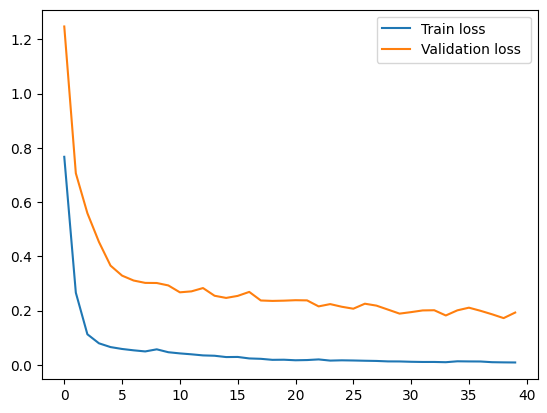

In [53]:
from energy_fault_detector.utils.visualisation import plot_learning_curve

plot_learning_curve(fd)

## Predict anomaly scores

In [54]:
results = fd.predict(sensor_data=sensor_data)
score_df = pd.DataFrame({
    'anomaly_score': results.anomaly_score,
    'predicted_anomaly': results.predicted_anomalies.astype(int),
}).join(hdd_df[['failure']])
score_df['days_to_failure'] = (FAILURE_DATE - score_df.index).days
score_df

153/153 [==============================] - 0s 2ms/step


,anomaly_score,predicted_anomaly,failure,days_to_failure
2020-01-07,1.318473,0,0,609
2020-01-08,0.868963,0,0,608
2020-01-09,0.785924,0,0,607
2020-01-10,0.738207,0,0,606
2020-01-11,0.698254,0,0,605
...,...,...,...,...
2021-09-03,9.105887,1,0,4
2021-09-04,9.073584,1,0,3
2021-09-05,9.063096,1,0,2
2021-09-06,9.064049,1,0,1


# Visualize Anomaly Scores

153/153 [==============================] - 0s 3ms/step


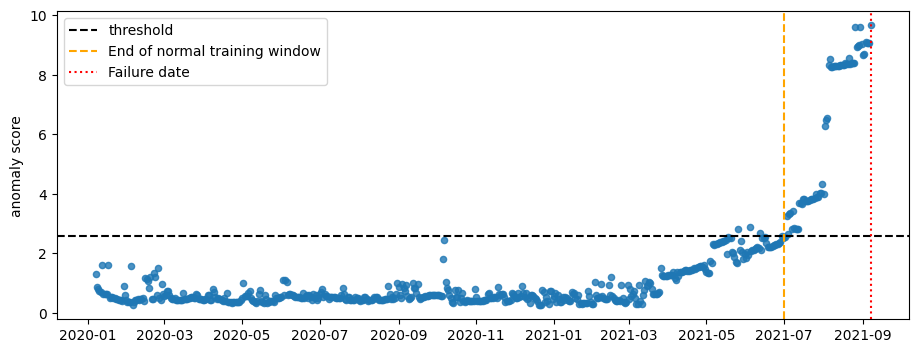

In [55]:
from energy_fault_detector.utils.visualisation import plot_score_with_threshold

fig, ax = plt.subplots(figsize=(11, 4))
plot_score_with_threshold(fd, sensor_data, ax=ax, marker_size=20)
ax.axvline(train_end, color='orange', linestyle='--', label='End of normal training window')
ax.axvline(FAILURE_DATE, color='red', linestyle=':', label='Failure date')
ax.legend(loc='upper left')

# TODO: Interpretation
Interpretation of the detected fault.

## Compare normal and pre-failure score levels

In [56]:
summary = pd.Series({
    'mean_score_training_window': score_df.loc[score_df.index <= train_end, 'anomaly_score'].mean(),
    'mean_score_pre_failure_window': score_df.loc[score_df.index > train_end, 'anomaly_score'].mean(),
    'predicted_anomalies_pre_failure': int(score_df.loc[score_df.index > train_end, 'predicted_anomaly'].sum()),
    'predicted_anomalies_total': int(score_df['predicted_anomaly'].sum()),
})
summary

mean_score_training_window          0.807039
mean_score_pre_failure_window       6.217348
predicted_anomalies_pre_failure    67.000000
predicted_anomalies_total          71.000000
dtype: float64

# Root Cause Analysis

In [57]:
error_event_index = pd.Series(sensor_data.index >= FAILURE_DATE - pd.Timedelta(days=14), index=sensor_data.index)
results_rca = fd.run_root_cause_analysis(sensor_data=sensor_data[error_event_index])

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='ARCANA importance'>)

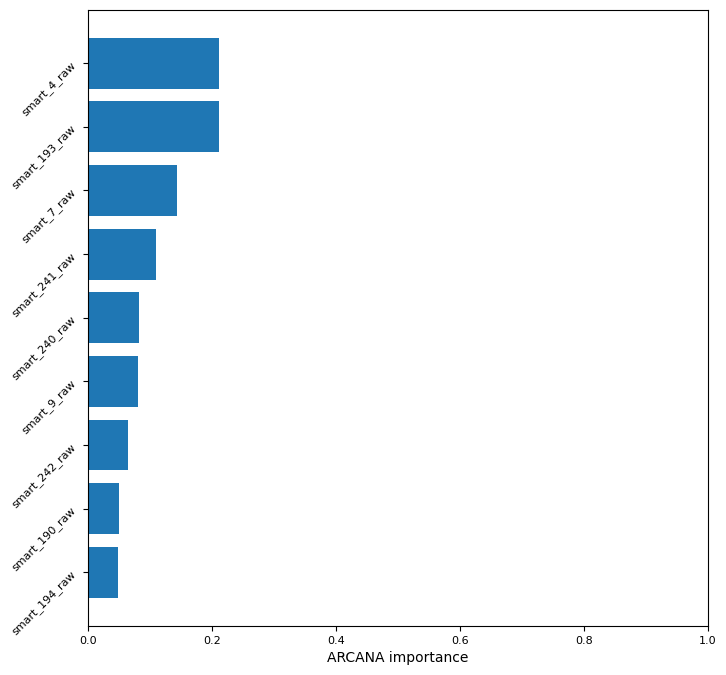

In [58]:
from energy_fault_detector.root_cause_analysis.arcana_utils import calculate_mean_arcana_importances
from energy_fault_detector.utils.visualisation import plot_arcana_mean_importances

importances = calculate_mean_arcana_importances(bias_data = results_rca[0])
plot_arcana_mean_importances(importances)

# Comparison to a baseline model

Epoch 1/40
55/55 [==============================] - 1s 5ms/step - loss: 0.8201 - mean_absolute_error: 0.7022 - val_loss: 0.5406 - val_mean_absolute_error: 0.5133
Epoch 2/40
55/55 [==============================] - 0s 2ms/step - loss: 0.3614 - mean_absolute_error: 0.3904 - val_loss: 0.1213 - val_mean_absolute_error: 0.2407
Epoch 3/40
55/55 [==============================] - 0s 2ms/step - loss: 0.0742 - mean_absolute_error: 0.1929 - val_loss: 0.0340 - val_mean_absolute_error: 0.1281
Epoch 4/40
55/55 [==============================] - 0s 2ms/step - loss: 0.0411 - mean_absolute_error: 0.1308 - val_loss: 0.0274 - val_mean_absolute_error: 0.1127
Epoch 5/40
55/55 [==============================] - 0s 2ms/step - loss: 0.0347 - mean_absolute_error: 0.1169 - val_loss: 0.0237 - val_mean_absolute_error: 0.1020
Epoch 6/40
55/55 [==============================] - 0s 2ms/step - loss: 0.0321 - mean_absolute_error: 0.1109 - val_loss: 0.0239 - val_mean_absolute_error: 0.1056
Epoch 7/40
55/55 [==========

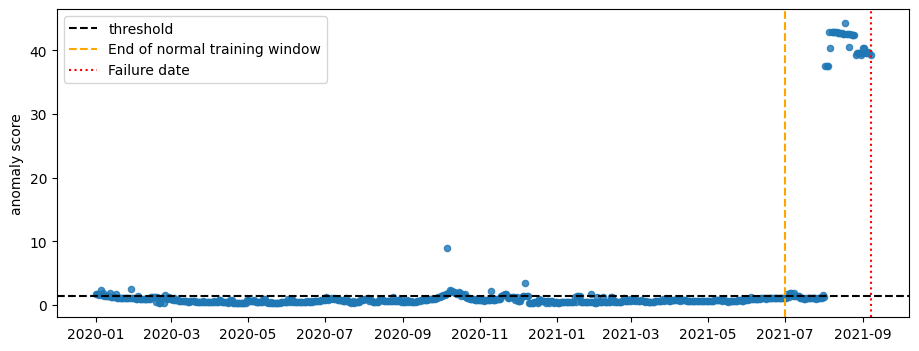

In [59]:
config = Config("./base_model.yaml")
base_fd = FaultDetector(config=config)
fit_result = base_fd.fit(sensor_data=sensor_data, normal_index=normal_index, save_models=False)

fig, ax = plt.subplots(figsize=(11, 4))
plot_score_with_threshold(base_fd, sensor_data, ax=ax, marker_size=20)
ax.axvline(train_end, color='orange', linestyle='--', label='End of normal training window')
ax.axvline(FAILURE_DATE, color='red', linestyle=':', label='Failure date')
ax.legend(loc='upper left')

# TODO: Interpretation


(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='ARCANA importance'>)

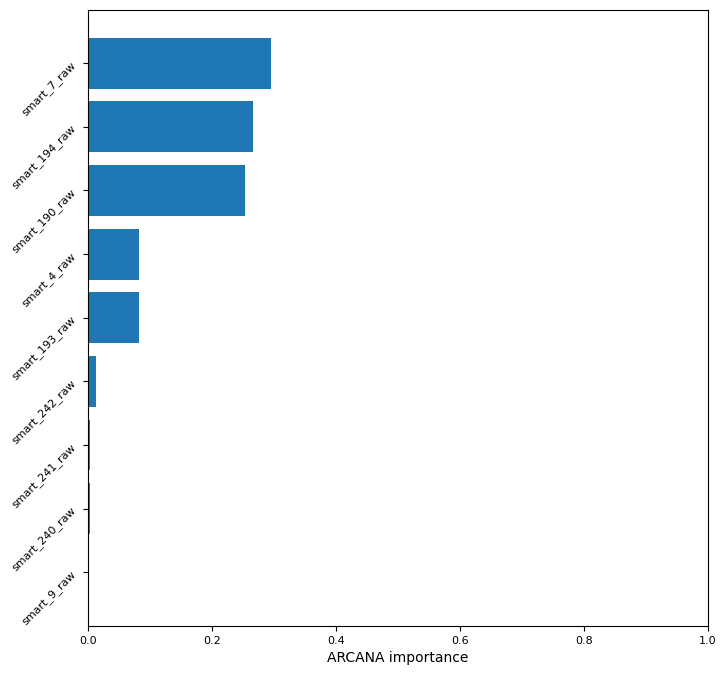

In [60]:
base_results_rca = base_fd.run_root_cause_analysis(sensor_data=sensor_data[error_event_index])
base_importances = calculate_mean_arcana_importances(bias_data=base_results_rca[0])
plot_arcana_mean_importances(base_importances)